# Predicting Tip Amounts for NYC Yellow Taxi Trips in Q1 2026

Unit: SIT220 Data Wrangling

Name: Damien Russell Hudoyo

Student Number: s224929574

Email: s224929574@deakin.edu.au

Course: Undergraduate (SIT220)


## Introduction

This report shows an end to end data wrangling and modelling pipeline applied to the NYC and TLC Yellow Taxi trip datasets. We start with raw monthly PARQUET files and I developed a reproducible pipeline that cleans the data and I also trained models to estimate the tip amount of credit card taxi trips. The goal is to create an accurate predictive model whilst also demonstrating a proper path from raw data to trained model by going through every stage of the workflow which are: data acquisition, data wrangling and preprocessing, feature engineering, modelling, evaluation and understanding the problems that we come across along the way.

### Choice of dataset

I chose the Yellow Taxi dataset because it is the largest and most documented dataset from TLC with detailed fare and tip information for credit card transactions. I chose to create a model that predicts the tip amount because it is particularly interesting in that it depends on a lot of factors that will be interesting to find out such as the rider's behaviour, the time of day, location or the structure of the fare itself.

### Choice of tooling and scope

In this task, there are 3 implementation pathways that we can select: a Pandas-based workflow, a PySpark-based workflow or a team-based commodity cluster. I selected the Pandas pathway for several reasons.

The first reason is that 3 months of Yellow Taxi data contains around 11 million trips which is large enough to capture meaningful variation in data on features like time of day, day of week, location and fare structure while still staying within the memory limitations of a single machine.

In the modelling stage, I will be implementing some machine learning to create predictive models. When involving much bigger datasets such as one that requires a PySpark-based workflow, training machine learning models can take an exponentially longer time which is why I chose to keep the scope small enough to be manageable but not too small that we aren't able to derive any meaningful information out of the data.

Overall, a PySpark-based workflow would have enabled a much larger scope such as going through multiple years of data but the additional scale will not have produced much more meaningful analytical value for the modelling question that we aim to address here.

### Scope

This analysis covers January, February and March 2026, the most recent quarter for which the TLC data was available at the time. This quarter captures variations across early winter and early spring travel patterns and the cleaned dataset contains approximately 6.7 million credit card paid trips after filtering has been done.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1) Loading the Data
We will work with 3 Yellow Taxi monthly datasets which covers January, February and March 2026. We will also use the taxi zone lookup data. These files are downloaded directly from the NYC TLC website and is stored locally. We will be using pandas to read the PARQUET files and the CSV lookup file.

In [2]:
jan = pd.read_parquet("yellow_tripdata_2026-01.parquet")
feb = pd.read_parquet("yellow_tripdata_2026-02.parquet")
mar = pd.read_parquet("yellow_tripdata_2026-03.parquet")
zones = pd.read_csv("taxi_zone_lookup.csv")

Before combining the 3 monthly files, I will check whether the columns of the 3 monthly files match before joining the tables. If there are differences in column names or datatypes then it will silently produce a deformed dataset.

In [3]:
# Check that the columns match across the three monthly files
print("Columns match:", list(jan.columns) == list(feb.columns) == list(mar.columns))
print("Datatypes match (jan vs feb):", jan.dtypes.equals(feb.dtypes))
print("Datatypes match (jan vs mar):", jan.dtypes.equals(mar.dtypes))
print(f"\nRow counts:")
print(f"  January:  {len(jan):,}")
print(f"  February: {len(feb):,}")
print(f"  March:    {len(mar):,}")

Columns match: True
Datatypes match (jan vs feb): True
Datatypes match (jan vs mar): True

Row counts:
  January:  3,724,889
  February: 3,399,866
  March:    3,952,451


All 3 monthly datasets' columns match each other which means that we can safely concatenate them together without any column or datatype mismatch issue.

In [4]:
df = pd.concat([jan, feb, mar], ignore_index=True)
# Delete them to save memory
del jan, feb, mar
print(df.shape)

(11077206, 20)


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11077206 entries, 0 to 11077205
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee         

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,1.107721e+07,11077206,11077206,8.020083e+06,1.107721e+07,8.020083e+06,1.107721e+07,1.107721e+07,1.107721e+07,1.107721e+07,1.107721e+07,1.107721e+07,1.107721e+07,1.107721e+07,1.107721e+07,1.107721e+07,8.020083e+06,8.020083e+06,1.107721e+07
mean,1.876552e+00,2026-02-15 16:11:28.931824,2026-02-15 16:28:54.533629,1.238929e+00,6.221664e+00,5.384528e+00,1.613870e+02,1.608872e+02,8.508780e-01,2.124950e+01,1.053296e+00,4.862019e-01,2.706643e+00,5.067500e-01,9.509915e-01,2.979328e+01,2.172388e+00,1.494923e-01,5.241209e-01
min,1.000000e+00,2008-12-31 23:03:20,2009-01-01 00:07:36,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-2.555200e+03,-7.500000e+00,-5.000000e-01,-8.888000e+01,-1.117900e+02,-1.000000e+00,-2.560200e+03,-2.500000e+00,-2.000000e+00,-7.500000e-01
25%,2.000000e+00,2026-01-24 00:02:16,2026-01-24 00:16:40,1.000000e+00,1.000000e+00,1.000000e+00,1.140000e+02,1.070000e+02,0.000000e+00,1.000000e+01,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.725000e+01,2.500000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,2026-02-14 21:54:05,2026-02-14 22:12:57,1.000000e+00,1.800000e+00,1.000000e+00,1.610000e+02,1.620000e+02,1.000000e+00,1.560000e+01,0.000000e+00,5.000000e-01,2.000000e+00,0.000000e+00,1.000000e+00,2.355000e+01,2.500000e+00,0.000000e+00,7.500000e-01
75%,2.000000e+00,2026-03-10 14:52:12,2026-03-10 15:13:28,1.000000e+00,3.700000e+00,1.000000e+00,2.330000e+02,2.340000e+02,1.000000e+00,2.680000e+01,2.500000e+00,5.000000e-01,3.850000e+00,0.000000e+00,1.000000e+00,3.471000e+01,2.500000e+00,0.000000e+00,7.500000e-01
max,7.000000e+00,2026-04-01 00:06:25,2026-04-02 16:03:47,9.000000e+00,3.285222e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,2.555200e+03,2.071000e+01,4.750000e+00,7.660000e+02,1.400000e+03,1.000000e+00,2.560200e+03,2.500000e+00,2.700000e+01,7.500000e-01
std,7.105294e-01,NaN,NaN,6.461159e-01,6.207150e+02,2.003832e+01,6.690951e+01,7.093040e+01,6.758964e-01,1.873519e+01,1.718890e+00,1.025176e-01,3.892603e+00,2.179020e+00,2.492188e-01,2.237361e+01,9.048935e-01,5.378711e-01,3.523499e-01


Looking at the outputs above, we can see that there are several issues. Looking at the timestamps, some datapoints go all the way back to 2008 which is far outside our analysis window of Q1 2026. This is most likely caused by taxi meters having incorrect date settings. We also have several negative values in monetary columns such as fare_amount, tip_amount, tolls_amount, and total_amount. Negative monetary values are not realistic, so these are most likely refunds or corrections rather than their actual values. There are also extreme positive values, such as trip distances above 328,000 miles which is farther than the distance from Earth to the moon which indicates that there could be errors during data collection such as sensor errors. Finally, several columns including passenger_count have missing values. These findings will be addressed in the cleaning step below.

Before cleaning the data, I will also check whether there are duplicate rows or not (rows that are perfectly identical to another)

In [6]:
# Check for exact duplicate rows in the combined dataset
duplicate_count = df.duplicated().sum()
print(f"duplicate rows: {duplicate_count:,}")

duplicate rows: 0


The dataset contains exactly 0 duplicate rows so there won't be a need to deduplicate during cleaning.

## 2) Cleaning the Data
Next, I took several measures to clean the data. First I removed any records that are out of the range we are analyzing which is Q1 of 2026. Next I removed any trips that are impossible such as having a dropoff time that is earlier than the pickup time, having negative or abnormally long distances, having a negative or abnormally large cost or having negative tips or abnormally large tips. I also filtered the data to only include credit card payments as it is the only payment type that tracks tips. Some data does not record number of passengers so I just filled it with the median as it does not affect tip amount. I also kept track of how much the number of datapoints decreases after every filter.

In [7]:
# 1. There are some records that took place outside of the 3 months we're analyzing so we will remove those
# as they're most likely errors or misinputs.
df = df[
    (df['tpep_pickup_datetime'] >= '2026-01-01') &
    (df['tpep_pickup_datetime'] <  '2026-04-01')
]
print(f"After date filter: {len(df):,}")

# 2. If the dropoff time is earlier than the pickup time then it is not possible so drop those
df = df[df['tpep_dropoff_datetime'] > df['tpep_pickup_datetime']]
print(f"After time order check: {len(df):,}")

# 3. If the trip has negative distance or if it is abnormally long such as being above 100 miles then drop it
df = df[(df['trip_distance'] > 0) & (df['trip_distance'] < 100)]
print(f"After distance filter: {len(df):,}")

# 4. If the trip has a negative fare cost or an abnormally expensive fare cost then drop it
df = df[(df['fare_amount'] > 0) & (df['fare_amount'] < 500)]
print(f"After fare filter: {len(df):,}")

# 5. If the trip has negative tips or abnormally large tips then drop it
df = df[(df['tip_amount'] >= 0) & (df['tip_amount'] < 200)]
print(f"After tip filter: {len(df):,}")

# 6. Only include credit card payments (payment_type 1) as tips can only be counted on credit card payments
df = df[df['payment_type'] == 1]
print(f"After payment filter: {len(df):,}")

# 7. Some data does not record number of passengers so just fill it with the median as it does not affect tip amount
df['passenger_count'] = df['passenger_count'].fillna(df['passenger_count'].median())

df = df.reset_index(drop=True)
print(f"\nFinal rows: {len(df):,}")

After date filter: 11,077,196
After time order check: 10,942,395
After distance filter: 10,575,328
After fare filter: 10,489,173
After tip filter: 10,489,159
After payment filter: 6,739,880

Final rows: 6,739,880


As we can see from the results above, we ended up with around 6.7 million datapoints which is around 60% of the original dataset. The biggest filter was only including credit card payments as a large chunk of payments occur in other forms such as cash which we don't include as credit card payments are the only type that records tip amounts. I acknowledge that this filter introduces selection bias as our results only tracks credit-card payments and not all trips.

## 3) Feature Engineering

After cleaning the dataset, I will now engineer new features that capture information not directly present in the raw data but that may help predict the tipping amount. Each feature will be created with a specific reason about how it might influence the tipping amount.

First, I created time based features such as pickup_hour, pickup_dayofweek and pickup_month. These features are based on the idea that tipping is behavioural and that the behaviours of riders vary by time. For example late night riders may tip differently from other periods of time, weekend trips can also serve a different types of riders in general. I also included the month which could capture any short term variation that happens across Q1.

Next, I created trip related features such as trip_duration_minutes and avg_speed_mph. These capture aspects of the trip that distance alone misses. Trip duration tells us how much time the rider actually spent in the cab which could influence the rider's experience and thus the tipping amount such as being stuck for a long time in traffic or taking a long journey to the airport. Average speed on the other hand captures whether the trip was smooth or not which may affect rider satisfaction which could affect tipping.

Next, I created a feature derived from the fare cost which is fare per mile. This allows us to determine the value that the riders are getting from these trips. A low fare per mile could mean that the rider is getting great value and that they may tip differently because of it.

Next, I created location features such as pickup_borough and dropoff_borough which came from joining the trip records with the taxi zone lookup table. Different boroughs could serve different types of riders, Manhaattan is very urban and has a lot of business and tourist traffic while other boroughs serve more local trips. The tipping amount could vary between these different boroughs.

Finally, I added a binary flag is_airport_trip that determines whether the trip involves an airport or not. This is useful as trips involving airports have different characteristics compared to standard trips. Airport trips are usually longer, have flat fare rates and serve different types of riders such as tourists. Having this binary flag can let the differences between airport and non-airport trips.

In [8]:
# column for day of the week and month
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
# day of week where monday will be 0 up to sunday which will be 6
df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek
# month of the year where January will be 1 and December will be 12
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month

# column for trip duration and average speed
df['trip_duration_minutes'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
df['avg_speed_mph'] = df['trip_distance'] / (df['trip_duration_minutes'] / 60)

# column for cost per unit distance (miles)
df['fare_per_mile'] = df['fare_amount'] / df['trip_distance']

# Adding actual pick up and drop off locations using the location ID on the boroughs
df = df.merge(
    zones[['LocationID', 'Borough']].rename(columns={'LocationID': 'PULocationID', 'Borough': 'pickup_borough'}),
    on='PULocationID', how='left'
)
df = df.merge(
    zones[['LocationID', 'Borough']].rename(columns={'LocationID': 'DOLocationID', 'Borough': 'dropoff_borough'}),
    on='DOLocationID', how='left'
)

# Add whether trip involves an airport as pick up or drop of, airport location IDs are 1, 132, 138
airport_ids = [1, 132, 138]
df['is_airport_trip'] = df['PULocationID'].isin(airport_ids) | df['DOLocationID'].isin(airport_ids)

df[['pickup_hour', 'pickup_dayofweek', 'pickup_month','trip_duration_minutes', 'avg_speed_mph', 'fare_per_mile', 'pickup_borough', 'dropoff_borough', 'is_airport_trip']].head()

,pickup_hour,pickup_dayofweek,pickup_month,trip_duration_minutes,avg_speed_mph,fare_per_mile,pickup_borough,dropoff_borough,is_airport_trip
0,0,3,1,5.550000,10.486486,7.422680,Manhattan,Manhattan,False
1,0,3,1,8.883333,9.455910,7.642857,Manhattan,Manhattan,False
2,0,3,1,42.800000,7.822430,6.935484,Manhattan,Manhattan,False
3,0,3,1,13.500000,9.600000,6.250000,Manhattan,Manhattan,False
4,0,3,1,13.600000,10.279412,6.094421,Manhattan,Manhattan,False


In [9]:
# Check the values of the new features
print(df[['trip_duration_minutes', 'avg_speed_mph', 'fare_per_mile']].describe())

       trip_duration_minutes  avg_speed_mph  fare_per_mile
count           6.739880e+06   6.739880e+06   6.739880e+06
mean            1.785357e+01   1.064661e+01   1.265786e+01
std             2.590819e+01   3.110914e+01   1.571475e+02
min             1.666667e-02   2.102067e-03   3.984064e-04
25%             7.766667e+00   6.713287e+00   5.821429e+00
50%             1.283333e+01   8.961039e+00   7.482517e+00
75%             2.133333e+01   1.218750e+01   9.565217e+00
max             1.777267e+03   3.700800e+04   4.520000e+04


After deriving the new features and printing out the summary statistics, we can see several problems. The maximum trip duration is nearly 30 hours, the maximum average speed exceeds 37,000 miles per hour, and the maximum fare per mile exceeds $45,000. These extreme values came from dividing by very small numbers for example, a trip with a duration of one second produces an enormous speed value when distance is divided by it. Our data cleaning earlier filtered out the upper bound of the distances and durations but it did not filter out meaningful lower bounds. These appear to be outliers caused by sensor or data entry errors so I will apply a further filter to keep the derived features within a reasonable range.

In [10]:
# Filter out implausible values
before = len(df)
df = df[
    # at least 1 minute
    (df['trip_duration_minutes'] >= 1) &
    # at most 3 hours
    (df['trip_duration_minutes'] <= 180) &
    # realistic speed limit of taxis
    (df['avg_speed_mph'] <= 80) &
    # cap the fare cost per mile at 100 which is generous
    (df['fare_per_mile'] <= 100)
]
df = df.reset_index(drop=True)
print(f"Rows removed by post-engineering filter: {before - len(df):,}")
print(f"Final dataset size: {len(df):,}")

Rows removed by post-engineering filter: 21,885
Final dataset size: 6,717,995


In [11]:
df[['trip_duration_minutes', 'avg_speed_mph', 'fare_per_mile']].describe()

,trip_duration_minutes,avg_speed_mph,fare_per_mile
count,6.717995e+06,6.717995e+06,6.717995e+06
mean,1.751411e+01,1.050514e+01,8.190844e+00
std,1.554311e+01,6.124471e+00,4.118554e+00
min,1.000000e+00,9.708738e-02,3.984064e-04
25%,7.800000e+00,6.716418e+00,5.818966e+00
50%,1.286667e+01,8.958525e+00,7.473684e+00
75%,2.135000e+01,1.217160e+01,9.555556e+00
max,1.799667e+02,8.000000e+01,1.000000e+02


Above we can see that we kept most of the rows whilst removing all the outliers and the max speed is now 80 miles per hour instead of being 37,000 and that the max trip duration is now within 2 hours instead of nearly 30.

## 4) Modelling
### Selecting Features

Before training, we explicitly choose which columns from the raw and engineered data to use as features. This is important as the features we choose will determine what the model will learn. First, the features that I would include are trip_distance, fare_amount, passenger_count and tolls_amount because these show the main trip and fare information that is directly captured at the meter. I will also include pickup_hour, pickup_dayofweek, pickup_month, trip_duration_minutes, avg_speed_mph and fare_per_mile which are the features I engineered previously. I will also include the location features which are pickup_borough and dropoff_borough, these features will be one-hot encoded. Lastly I will include the is_airport_trip to flag whether it is a trip involving the airport or not.

There are many features that I deliberately excluded. First is total_amount which contains the total amount of the fare including the tip_amount which will give away what we are trying to predict. I will also not include timestamp features such as tpep_pickup_datetime as we are already including pickup_hour and trip_duration which is directly based off these features. I will also omit location IDs as we already have direct one hot coded columns. Next I excluded the payment_type because we filtered for credit card only which means this column will only contain 1 which is credit card which doesn't tell us anything. I will also exclude any additional fees such as surcharge or congestion fees as they are usually constant amounts and that we already have a column that flags if it is an airport trip so airport fees won't tell us much. Lastly I excluded every other column that are unlikely to reflect the rider's behaviour or tell us anything that will help in determining the tip amount such as VendorID, RatecodeID and store_and_fwd_flag.

The reason I selected specific features instead of using all of them is because a lot of these columns are very related which could introduce some redundancy and add more dimensions without necessarily adding more information. Columns like total_amount will also cause data leakage as it contains the target itself which is the tip amount.

In [12]:
# Choose features for modelling
feature_cols = [
    'trip_distance', 'fare_amount', 'passenger_count', 'tolls_amount',
    'pickup_hour', 'pickup_dayofweek', 'pickup_month',
    'trip_duration_minutes', 'avg_speed_mph', 'fare_per_mile',
    'pickup_borough', 'dropoff_borough', 'is_airport_trip'
]

# df with the features
X = df[feature_cols].copy()
# df with the target which is the tipping amount
y = df['tip_amount'].copy()

# One-hot encode the categorical features (boroughs)
X = pd.get_dummies(X, columns=['pickup_borough', 'dropoff_borough'], drop_first=True)

# Convert booleans to integers
X['is_airport_trip'] = X['is_airport_trip'].astype(int)

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeature columns:")
print(X.columns.tolist())

Feature matrix shape: (6717995, 23)
Target vector shape: (6717995,)

Feature columns:
['trip_distance', 'fare_amount', 'passenger_count', 'tolls_amount', 'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'trip_duration_minutes', 'avg_speed_mph', 'fare_per_mile', 'is_airport_trip', 'pickup_borough_Brooklyn', 'pickup_borough_EWR', 'pickup_borough_Manhattan', 'pickup_borough_Queens', 'pickup_borough_Staten Island', 'pickup_borough_Unknown', 'dropoff_borough_Brooklyn', 'dropoff_borough_EWR', 'dropoff_borough_Manhattan', 'dropoff_borough_Queens', 'dropoff_borough_Staten Island', 'dropoff_borough_Unknown']


### Splitting the Dataset
Before we start training models, we will need to split the dataset we have into a training and testing set. I will split the data in an 80/20 ratio which is the standard. The split will be random with a fixed random state to make the results reproducible.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=67
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")

Training set: 5,374,396 samples
Test set:     1,343,599 samples


### Training Baseline Model: Linear Regression
First we will train Linear Regression on the dataset which is our base model. The purpose of training this model is not to achieve the best possible output but to act as a baseline of the expected performance. Later we will train a random forest model which is more complex and should yield a better result.

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Train with linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on the test set
lr_preds = lr.predict(X_test)

# Evaluate the performance
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print(f"Linear Regression Performance:")
print(f"  RMSE: ${lr_rmse:.3f}")
print(f"  MAE:  ${lr_mae:.3f}")
print(f"  R^2:   {lr_r2:.4f}")

Linear Regression Performance:
  RMSE: $2.557
  MAE:  $1.431
  R^2:   0.5876


The baseline linear regression achieved an RMSE of 2.56, an MAE of 1.43 and an R^2 of 0.59. This means that on a typical trip, the model's prediction is about $1.43 away from the actual tip and that the model explains around 59% of the variance that we see in the tip amounts. The gap between RMSE and MAE shows that some predictions miss by a large margin as RMSE penalizes larger mistakes more.

The result shows clear limitations on using linear regression on this dataset. First, linear regression assumes that each feature contributes linearly to the target but tipping behaviour is unlikely to be linear. For example, the relationship between the pickup hour and tipping amount is most likely not linear as tips at certain times behave differently from other times and there could be certain periods of time affecting tipping but linear regression can only learn one weight per feature.

Next, there are several features that are encoded as numeric values which imply linear ordering such as the day of the week which is coded as 0-6 which implies that Sunday is "more" than Saturday numerically which is not true at all, this also implies that Sunday has 6x the effect that Tuesday has. The same applies for pickup hour or pickup month as these values are more categorical and not linear. A solution to this is to one-hot encode these features, but I chose to keep them as numeric for consistency across all the models that we will train, tree-based models like random forest which is trained later handles these non one-hot encoded features properly.



### Hyperparameter tuning for random forest

Before training the random forest on the full training set, I will tune the hyperparameters in order to find the best parameters for the full training set. Tuning directly on the whole dataset would be infeasible because it will be computationally expensive, so I took a subset of 200k samples for hyperparameter tuning and then I will train the final model on the full dataset with the best hyperparameters found. For the tuning, I did a grid search on 3 hyperparameters which are max_depth (how deep the trees can grow), min_samples_leaf (minimum samples per leaf node) and the number of trees which is fixed at 100.

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Take a 200k subsample for hyperparameter tuning
sample_idx = X_train.sample(n=200_000, random_state=67).index
X_sample = X_train.loc[sample_idx]
y_sample = y_train.loc[sample_idx]

# Define all the hyperparameter values that we will test
# We will test all possible combinations as a grid search
param_grid = {
    'max_depth': [10, 15, 20, None],
    'min_samples_leaf': [5, 20, 50],
    'n_estimators': [100],
}

# 3 fold cross validation and we find the best value which is the model with the least RMSE
# Grid search will be trained sequentially (n_jobs=1) and for each forest we will train with all cores (n_jobs=-1)
grid_search = GridSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=67),
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=1,
    verbose=2
)

grid_search.fit(X_sample, y_sample)

print("\nBest parameters:")
print(grid_search.best_params_)
print(f"Best CV RMSE: ${-grid_search.best_score_:.3f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END .max_depth=10, min_samples_leaf=5, n_estimators=100; total time=   3.9s
[CV] END .max_depth=10, min_samples_leaf=5, n_estimators=100; total time=   3.8s
[CV] END .max_depth=10, min_samples_leaf=5, n_estimators=100; total time=   3.9s
[CV] END max_depth=10, min_samples_leaf=20, n_estimators=100; total time=   3.9s
[CV] END max_depth=10, min_samples_leaf=20, n_estimators=100; total time=   3.9s
[CV] END max_depth=10, min_samples_leaf=20, n_estimators=100; total time=   3.8s
[CV] END max_depth=10, min_samples_leaf=50, n_estimators=100; total time=   3.7s
[CV] END max_depth=10, min_samples_leaf=50, n_estimators=100; total time=   3.7s
[CV] END max_depth=10, min_samples_leaf=50, n_estimators=100; total time=   3.7s
[CV] END .max_depth=15, min_samples_leaf=5, n_estimators=100; total time=   5.4s
[CV] END .max_depth=15, min_samples_leaf=5, n_estimators=100; total time=   5.4s
[CV] END .max_depth=15, min_samples_leaf=5, n_es

As we can see from the result, the best hyperparameters are: max_depth=15 and min_samples_leaf=20. There is only 1 value of n_estimators which is 100 so that stays the same. Next, we are going to train random forest on the full dataset using these hyperparameters.

In [16]:
from sklearn.ensemble import RandomForestRegressor

# Train random forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=20,
    # n_jobs=-1 to use all cpu cores and speed up the training
    n_jobs=-1,
    random_state=67
)
rf.fit(X_train, y_train)

# Predict on the test set
rf_preds = rf.predict(X_test)

# Evaluate the performance
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print(f"Random Forest Performance:")
print(f"  RMSE: ${rf_rmse:.3f}")
print(f"  MAE:  ${rf_mae:.3f}")
print(f"  R^2:   {rf_r2:.4f}")

Random Forest Performance:
  RMSE: $2.381
  MAE:  $1.261
  R^2:   0.6424


As we can see from the results, the random forest achieves an RMSE of 2.38, an MAE of 1.26 and an R^2 of 0.64. Compared to the linear regression baseline (RMSE 2.56, MAE 1.43 R^2 0.59), the random forest performed better by reducing typical prediction error by about 12% and it also explains 5% more variance. This improvement is noticeable but smaller than I expected. This shows that what makes tips predictable is roughly linear as the model didn't improve by much compared to linear regression. The non-linear features that random forest can exploit such as hour of day or day of week contribute to some performance gains but not by much. With 64% of the variance explained, there is still about 36% of variance that is unexplained. This result is telling because it most likely reflects noise that is behavioural which is not captured by the features in the dataset. This shows the true limitation in predicting the tip amounts as it depends on factors like the behaviour, mood or habits of the rider or maybe even the rider's background which the dataset does not show.

### Feature Importance
Getting the performance results is one thing but we can go further and see which features contribute to the model the most and why.

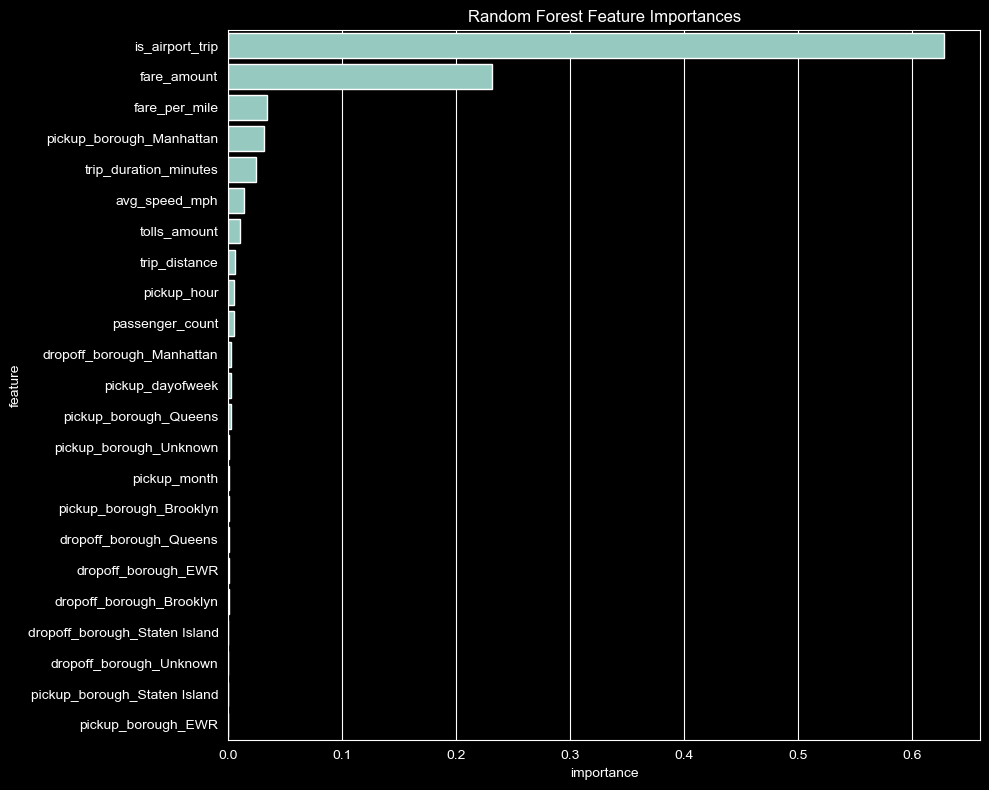


Top features by importance:
                 feature  importance
         is_airport_trip    0.628100
             fare_amount    0.231093
           fare_per_mile    0.033943
pickup_borough_Manhattan    0.030917
   trip_duration_minutes    0.024585
           avg_speed_mph    0.013922
            tolls_amount    0.010273
           trip_distance    0.005819
             pickup_hour    0.005305
         passenger_count    0.004969


In [17]:
# Get the importance of features from the trained random forest
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# Plot the graph
plt.figure(figsize=(10, 8))
sns.barplot(data=importances, x='importance', y='feature')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()

# Print the top features
print("\nTop features by importance:")
print(importances.head(10).to_string(index=False))

Above, we can see that the feature is_airport_trip is by far the most influential feature, followed by fare_amount with all the other features contributing relatively small amounts. This is quite surprising as airport trips only make up about 9% of the dataset. My theory is that airport trips are just inherently different from normal types of trips, airport trips likely involve people who are in a rush which could yield to more tips, airport trips also involve tourists who may be more stingy or relaxed. In order to investigate further, I compared the tip statistics for airport trips against non-airport trips to see the difference. I will also compare the tip to fare ratios of airport trips and non-airport trips to see the tip rates based on the fare amount on the 2 groups.

In [18]:
# Compare tip behaviour for airport vs non-airport trips
print("Tip stats for airport trips:")
print(df[df['is_airport_trip']]['tip_amount'].describe())
print("\nTip stats for non-airport trips:")
print(df[~df['is_airport_trip']]['tip_amount'].describe())

# Compare tip-to-fare ratio
print("\nTip to fare ratio for airport trips:")
print((df[df['is_airport_trip']]['tip_amount'] / df[df['is_airport_trip']]['fare_amount']).describe())
print("\nTip to fare ratio for non-airport trips:")
print((df[~df['is_airport_trip']]['tip_amount'] / df[~df['is_airport_trip']]['fare_amount']).describe())

Tip stats for airport trips:
count    620343.000000
mean         12.150546
std           6.437921
min           0.000000
25%           8.650000
50%          12.210000
75%          16.300000
max         156.700000
Name: tip_amount, dtype: float64

Tip stats for non-airport trips:
count    6.097652e+06
mean     3.302428e+00
std      2.452643e+00
min      0.000000e+00
25%      2.000000e+00
50%      3.010000e+00
75%      4.270000e+00
max      1.500000e+02
Name: tip_amount, dtype: float64

Tip to fare ratio for airport trips:
count    620343.000000
mean          0.218334
std           0.110220
min           0.000000
25%           0.179857
50%           0.234857
75%           0.273036
max          13.181818
dtype: float64

Tip to fare ratio for non-airport trips:
count    6.097652e+06
mean     2.518360e-01
std      8.096380e-01
min      0.000000e+00
25%      1.840491e-01
50%      2.694444e-01
75%      3.225806e-01
max      1.900000e+03
dtype: float64


/var/folders/bp/s6pffhf14yj_tnxyzb85dc7w0000gn/T/ipykernel_17038/4204843452.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-Airport', 'Airport'])
/var/folders/bp/s6pffhf14yj_tnxyzb85dc7w0000gn/T/ipykernel_17038/4204843452.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-Airport', 'Airport'])


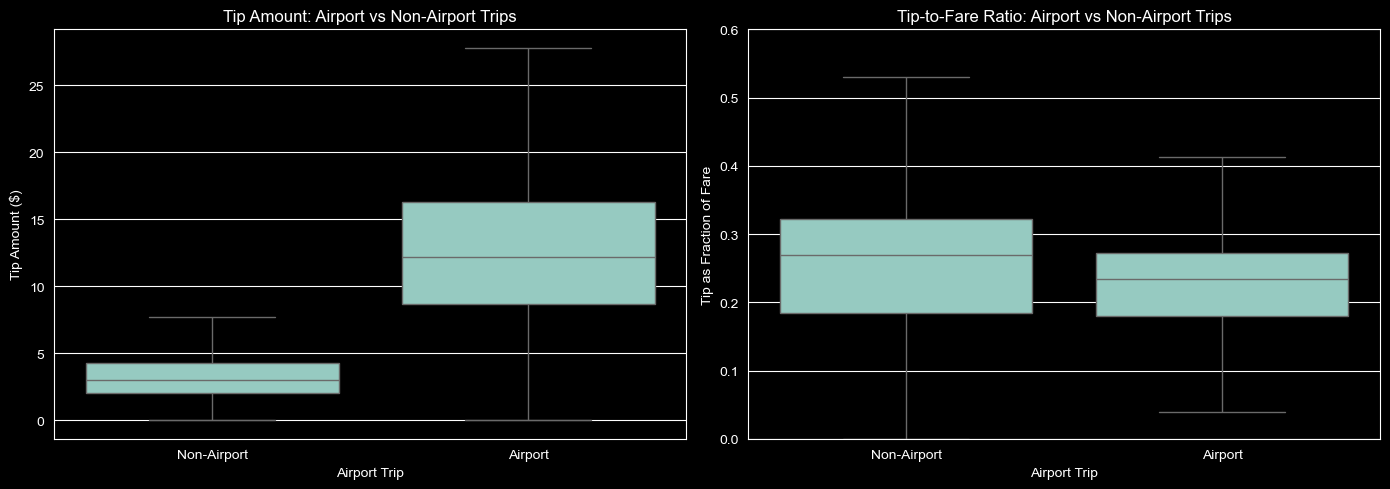

In [19]:
# Compute the tip-to-fare ratio for each trip to plot it
df['tip_to_fare_ratio'] = df['tip_amount'] / df['fare_amount']

# 2 plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compare dollar tip amounts
sns.boxplot(
    data=df,
    x='is_airport_trip',
    y='tip_amount',
    ax=axes[0],
    showfliers=False # showfliers=False to not include extreme outliers
)
axes[0].set_title('Tip Amount: Airport vs Non-Airport Trips')
axes[0].set_xlabel('Airport Trip')
axes[0].set_ylabel('Tip Amount ($)')
axes[0].set_xticklabels(['Non-Airport', 'Airport'])

# Compare tip to fare ratio
sns.boxplot(
    data=df,
    x='is_airport_trip',
    y='tip_to_fare_ratio',
    ax=axes[1],
    showfliers=False
)
axes[1].set_title('Tip-to-Fare Ratio: Airport vs Non-Airport Trips')
axes[1].set_xlabel('Airport Trip')
axes[1].set_ylabel('Tip as Fraction of Fare')
axes[1].set_xticklabels(['Non-Airport', 'Airport'])
axes[1].set_ylim(0, 0.6)

plt.tight_layout()
plt.show()

The results revealed several things. Airport trips have tip amounts roughly 4x larger (median of 12.21 vs 3.01) than non-airport trips. This is due to airport trips generally being a lot longer than non-airport trips and JFK in particular operating on a flat-rate fare structure. If we compared the tip to fare ratio or the tip amount as a percentage of the fare then the airport riders actually tip slightly less (median of 23.5% vs 26.9%) than non-airport riders. This shows how the true tip amount is based truly on the fare cost rather than whether it is an airport trip or not and that the is_airport_trip feature is just a tell on whether the trips are long or not.

Aside from airport trips or the fare amount, there are other factors that very slightly affect the tip rate. The pickup borough being in Manhattan shows a slight difference compared to it being in other boroughs. The trip duration, average speed and tolls amount also have a very slight effect on the tipping amount.

In conclusion, the is_airport_trip feature dominates not because a trip being an airport trip makes any significant difference but because airport trips are generally longer trips and thus making the fare amount relatively high. This also shows how is_airport_trip and fare_amount are highly correlated and that the model could have made similar predictions and gotten similar results just by using either is_airport_trip or fare_amount alone. is_airport_trip seems to dominate because it is a binary feature and so it allows a clean single split. The conclusion is that tipping in NYC taxis scales primarily with fare with airport trips representing longer trips than standard which shows a large difference in tipping amount.

Another aspect that we can analyze is whether temporal patterns exist in tipping. Below I created a visualization of the mean tip amount as well as the mean tip to fare ratio for every hour of the day.

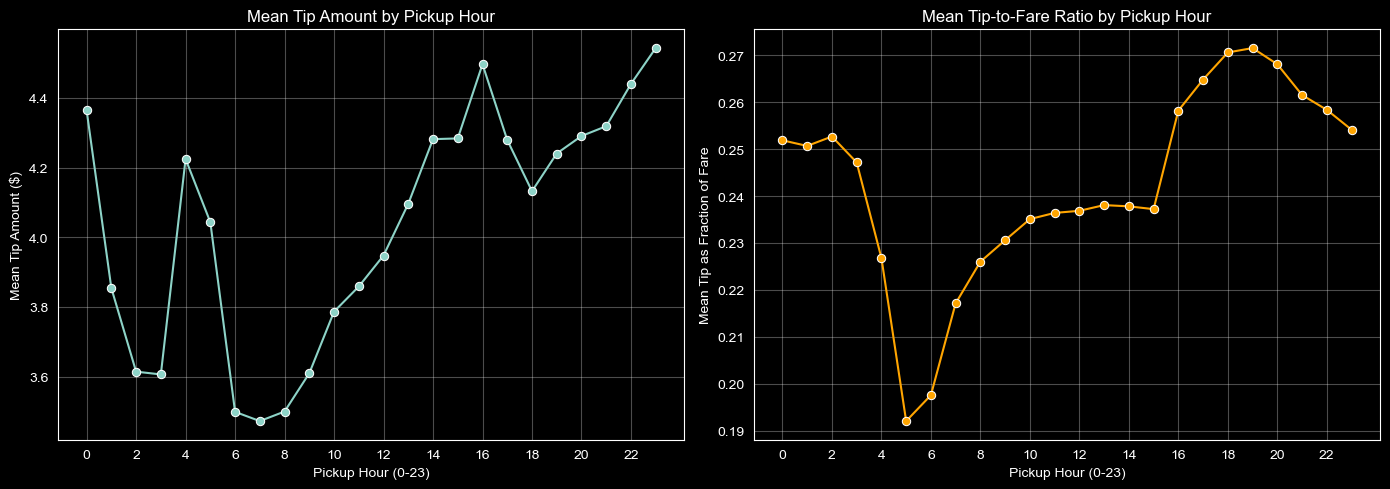

In [20]:
# calculate the mean tip amount and mean tip to fare ratio by pickup hour
hourly = df.groupby('pickup_hour').agg(
    mean_tip=('tip_amount', 'mean'),
    mean_ratio=('tip_to_fare_ratio', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean tip amount by hour
sns.lineplot(data=hourly, x='pickup_hour', y='mean_tip', marker='o', ax=axes[0])
axes[0].set_title('Mean Tip Amount by Pickup Hour')
axes[0].set_xlabel('Pickup Hour (0-23)')
axes[0].set_ylabel('Mean Tip Amount ($)')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(alpha=0.3)

# Mean tip-to-fare ratio by hour
sns.lineplot(data=hourly, x='pickup_hour', y='mean_ratio', marker='o', ax=axes[1], color='orange')
axes[1].set_title('Mean Tip-to-Fare Ratio by Pickup Hour')
axes[1].set_xlabel('Pickup Hour (0-23)')
axes[1].set_ylabel('Mean Tip as Fraction of Fare')
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

From the visualisations, we can see that the mean tip amount and the mean tip to fare ratio follow different shapes across the day. The tip amount is high in the late night hours (around 4.36 at midnight), dips overnight to around 3.47 at 7am, then steadily rises through the day and peaks again around 4.50 in the late evening. The tip to fare ratio follows a noticeably different shape. It is roughly flat overnight at around 25%, drops then climbs through the day to peak at 27% at 5pm.

This shows that pickup_hour captures a small behaviour component as riders behave differently on different times and that there are certain types of people that commute on certain times. Previously we discovered that the tip ratio for airport trips are slightly lower than normal trips. This is reflected in this visualization as we can see that the tip to fare ratio dips the most at 5am which is most likely when most airport travel activity happens. A large part of the tip amount variation throughout the day is also driven by the fare, longer overnight trips inflate the tip amount without changing the percentage. However, the ratio is not flat. It varies around 7% between low points like early morning and the peak at evening, this is a behavioural effect that fare cost can't explain on its own.

## 5) Limitations and Discussion

While the pipeline produces a working model with meaningful predictions, there are several important limitations that we should acknowledge.

### Selection bias from credit card filter
The biggest filter we made in the pipeline was restricting the analysis to only trips paid by credit card, as the TLC dataset does not record tip amounts for cash transactions. This removed around 1/3 of the original dataset and introduces selection bias because riders who pay by card may differ from riders who pay by cash in trip context, time of day, demographics, or other unobserved ways. Riders who pay by cash could potentially have different tipping behaviour given the circumstances. Our results therefore generalise only to credit-card-paid Yellow Taxi trips and not to the whole population of NYC taxi riders.

### Behavioural factors that are unobservable

Tipping is fundamentally a behavioural outcome that depends on the rider's mood, generosity, satisfaction, habits, and which button they tap on the payment screen. None of these are captured in the trip metadata available to us, which only records what happened during the trip such as the distance, fare, time, and location. This puts a ceiling on how well any model can predict tip amounts from this data. With access to more behavioural features such as the rider's history, the weather, specific events, or the rider's background, the model could likely improve further, although collecting this kind of data could raise privacy concerns such as re-identification.

### Scope of data

This analysis covers only the first quarter of 2026 (January, February, March). I chose this window for several reasons: it is large enough to capture meaningful patterns and small enough to allow rapid iteration during parts such as model tuning and training. However, restricting the analysis to one quarter limits the conclusions that we can draw. We cannot say anything about seasonal patterns, as that would require a full year of data in order to analyze features such as whether certain holidays affect tipping behaviour. We also cannot detect long-term trends across years. A more comprehensive study covering multiple years would allow us to analyze seasonal patterns as well as the long-term trends that may exist.

### Choices in thresholds for filtering outliers

We relied on several fixed thresholds during cleaning: trip distance below 100 miles, fares below 500, tips below 200, trip durations between 1 and 180 minutes, and average speeds below 80 mph. These thresholds were chosen to remove wild outliers (such as trips that exceeded 300,000 miles) rather than to perfectly classify borderline cases. The 99.9th percentile of average speed in the filtered dataset is 44 mph, well below our 80 mph cap, suggesting the thresholds we selected are quite generous in practice. A more rigorous approach could use statistics-based methods such as percentile or z-score thresholds to detect outliers more systematically.

## 6) Conclusion

This report presented an end-to-end data wrangling and modelling pipeline applied to NYC Yellow Taxi trip records from the first quarter of 2026. We started with raw PARQUET files and built a reproducible pipeline that cleaned the data, engineered new features derived from existing columns, and trained both a linear regression and a tuned random forest model to predict the tipping amount.

From the analysis, we found that linear regression can explain 59% of the variance in tip amounts, while random forest improved this to 64% which is a small but noticeable margin. Overall, the models did not perform particularly well because tipping is driven by behavioural factors that are not captured by any feature available in the dataset. Tipping in NYC taxis is therefore slightly predictable but inherently noisy, with a lot of variance driven by factors not captured in the data.

After training the tuned random forest model, I analysed which features were most important, which revealed several insights. While is_airport_trip appears dominant in the model, closer analysis shows that airport riders actually tip a lower percentage of the fare than non-airport riders. The high importance of is_airport_trip simply reflects how tipping amount is closely tied to fare amount, since airport trips tend to have higher fares. This is further supported by fare_amount being the second most dominant feature, and the model would likely produce similar results using either feature alone. Analyzing the temporal features also showed that while much of the variation in the tip amounts over different hours is fare-driven, the tip-to-fare ratio itself varies by around 7% across the day which indicates a small behavioural component beyond fare amount.

There are also other features that slightly contribute to the tipping amount such as pickup borough (Manhattan in particular), trip duration, and average speed.

A natural extension to this analysis would be to predict the tip percentage (tip as a fraction of the fare amount) rather than the absolute tip amount, which would isolate the behavioural component. Other useful extensions would be to cover a larger scope such as a full year or multiple years which would allow us to analyse seasonal patterns and long-term trends. Another useful extension would be to use datasets that include more behavioural information such as weather, rider history, or rider background, given that tipping appears to be driven largely by behavioural factors that are not in the TLC data.